In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import classification_report, confusion_matrix


import pickle

In [3]:
# load the tokenized and padded data

X_train = np.load("../data/tokenized/X_train.npy")
X_test = np.load("../data/tokenized/X_test.npy")

y_train = np.load("../data/tokenized/y_train.npy")
y_test = np.load("../data/tokenized/y_test.npy")

with open("../models/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [4]:
# model parameters

VOCAB_SIZE = len(tokenizer.word_index) + 1
MAX_LEN = X_train.shape[1]
EMBEDDING_DIM = 128
GRU_UNITS = 64
DROPOUT_RATE = 0.3
NUM_CLASSES = 5


In [5]:
# Building the model

model = Sequential([
    Input(shape = (MAX_LEN,)),
    
    Embedding(
        input_dim = VOCAB_SIZE,
        output_dim= EMBEDDING_DIM
    ),
    
    GRU(GRU_UNITS),
    
    Dropout(DROPOUT_RATE),
    
    Dense(64, activation= "relu"),
    
    Dropout(DROPOUT_RATE),
    
    Dense(NUM_CLASSES, activation= "softmax")
    
])

In [6]:
# Compile the model

model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │    13,292,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,334,277 (50.87 MB)

 Trainable params: 13,334,277 (50.87 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# defining callbacks

early_stopping = EarlyStopping(
    monitor= "val_loss",
    patience= 3,
    restore_best_weights= True
)

model_checkpoint = ModelCheckpoint(
    filepath= "../models/gru_model_v1.keras",
    monitor= "val_loss",
    save_best_only= True,
    verbose = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor= "val_loss",
    factor = 0.5,
    patience= 2,
    min_lr= 1e-6,
    verbose= 1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

In [9]:
# Train the model 

history = model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    epochs = 10,
    batch_size = 64,
    callbacks = callbacks
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2776 - loss: 1.5380
Epoch 1: val_loss improved from None to 1.15961, saving model to ../models/gru_model_v1.keras

Epoch 1: finished saving model to ../models/gru_model_v1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.2776 - loss: 1.5380 - val_accuracy: 0.4841 - val_loss: 1.1596 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5425 - loss: 1.0595
Epoch 2: val_loss improved from 1.15961 to 1.01127, saving model to ../models/gru_model_v1.keras

Epoch 2: finished saving model to ../models/gru_model_v1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 118s 94ms/step - accuracy: 0.5425 - loss: 1.0595 - val_accuracy: 0.5562 - val_loss: 1.0113 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5723 - loss: 0.9879
Epoch 3: val_loss improved from 1.01127 to 0.98803, saving model to ../models/gru_model_v1.keras

Epoch 3: finished saving

In [10]:
# save the history

with open("../models/gru_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

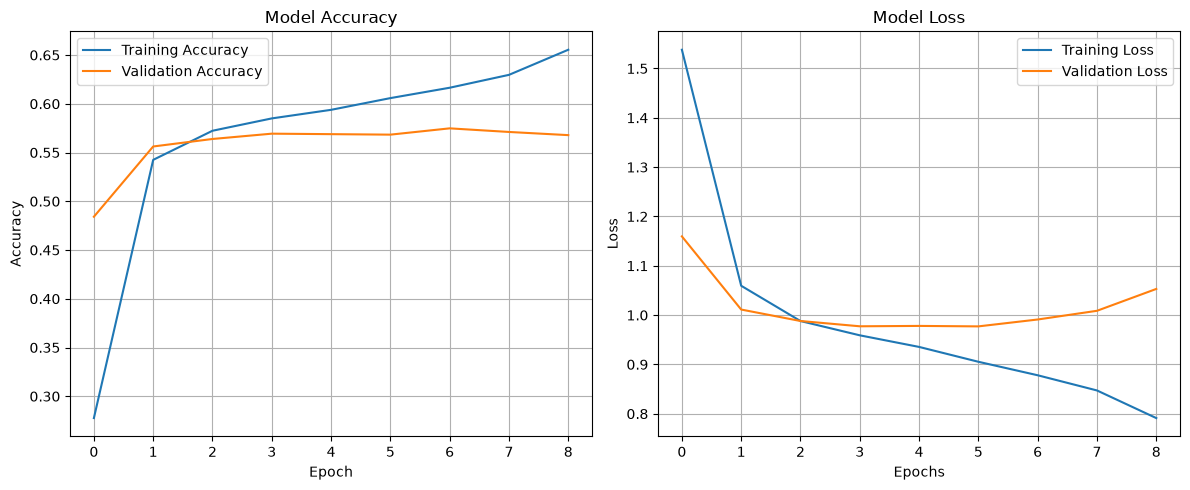

In [11]:
# Evaluation of model

plt.figure(figsize= (12, 5))

#accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Prediction

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis = 1)

625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step


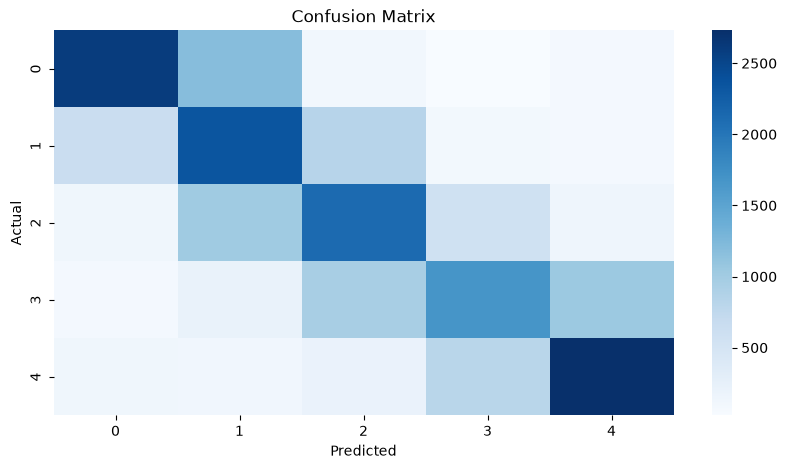

In [13]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize= (10, 5))
sns.heatmap(
    cm,
    fmt= "d",
    cmap = "Blues",
    xticklabels= [0, 1, 2, 3, 4],
    yticklabels= [0, 1, 2, 3, 4]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
#  Classification report

cr = classification_report(
    y_test, 
    y_pred
)

print(cr)

              precision    recall  f1-score   support

           0       0.72      0.65      0.68      4000
           1       0.48      0.59      0.53      4000
           2       0.50      0.53      0.51      4000
           3       0.53      0.42      0.47      4000
           4       0.67      0.68      0.68      4000

    accuracy                           0.57     20000
   macro avg       0.58      0.57      0.57     20000
weighted avg       0.58      0.57      0.57     20000

